# Lab Assignment 6: Introduction to IBM Qiskit


In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_bloch_multivector, plot_histogram, array_to_latex
from qiskit.quantum_info import Statevector, state_fidelity

# Aer simulator
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

print("All imports successful!")

All imports successful!


---
# Experiment 1: X-Gate on Bloch Sphere and State Vector

Create a quantum circuit with a single qubit and:
1. Apply X-Gate to the qubit
2. Draw the Circuit
3. Show the qubit on Bloch Sphere
4. Display the state vector of the quantum state

### 1.1 — Build and Draw the Circuit

Circuit with X Gate:


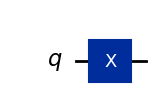

In [ ]:
# Build single-qubit circuit with X gate
qc_x = QuantumCircuit(1)
qc_x.x(0)

print("Circuit with X Gate:")
qc_x.draw('mpl')

### 1.2 — Bloch Sphere Visualization

The X gate flips $|0\rangle \rightarrow |1\rangle$, which moves the state from the north pole to the south pole of the Bloch sphere.

Bloch Sphere after X Gate (|0> -> |1>):


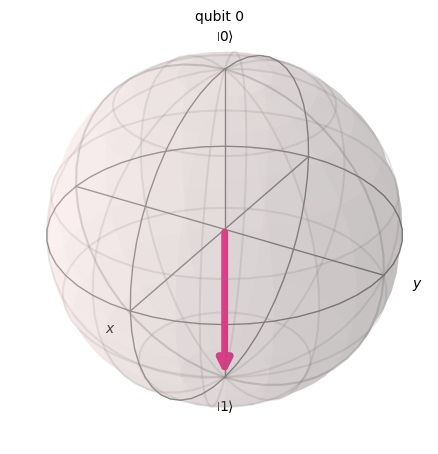

In [ ]:
# Get statevector using Statevector class
sv_x = Statevector(qc_x)

print("Bloch Sphere after X Gate (|0> -> |1>):")
plot_bloch_multivector(sv_x)

### 1.3 — State Vector Display

In [ ]:
print("State vector after X gate:")
display(array_to_latex(sv_x, prefix="|\\psi\\rangle = "))


print(f"\nNumerical statevector: {sv_x.data}")
print(f"Initial state |0>  : [1+0j, 0+0j]")
print(f"After X gate  |1>  : {list(sv_x.data)}")

State vector after X gate:


<IPython.core.display.Latex object>


Numerical statevector: [0.+0.j 1.+0.j]
Initial state |0>  : [1+0j, 0+0j]
After X gate  |1>  : [np.complex128(0j), np.complex128(1+0j)]


### 1.4 — Before and After Comparison

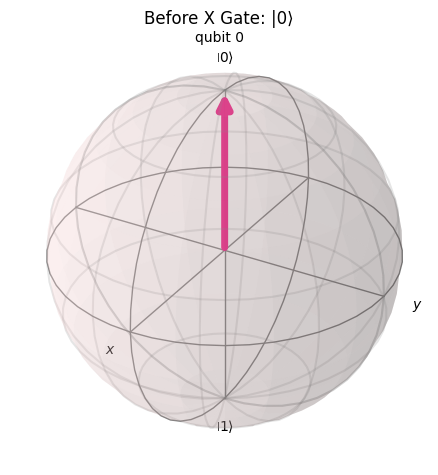

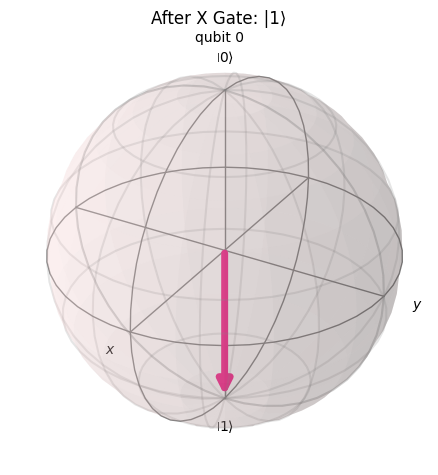

In [ ]:
# Compare |0> and |1> on Bloch sphere side by side
sv_0 = Statevector.from_label('0')  # |0>
sv_1 = Statevector(qc_x)            # |1> after X

fig, axes = plt.subplots(1, 2, figsize=(8, 4),
                          subplot_kw={'projection': '3d'})
plt.close()

fig_before = plot_bloch_multivector(sv_0)
fig_before.suptitle('Before X Gate: |0⟩', fontsize=12)

fig_after = plot_bloch_multivector(sv_1)
fig_after.suptitle('After X Gate: |1⟩', fontsize=12)

display(fig_before)
display(fig_after)

---
# Experiment 2: Single Qubit Gates on Bloch Sphere and State Vector

Repeat Experiment 1 for **Y, Z, Phase, S, S†, T, T†** gates with initial state:
$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) = |+\rangle$$

### 2.1 — Prepare Initial State $|+\rangle$

Initial state |+> = 1/sqrt(2)(|0> + |1>):


<IPython.core.display.Latex object>

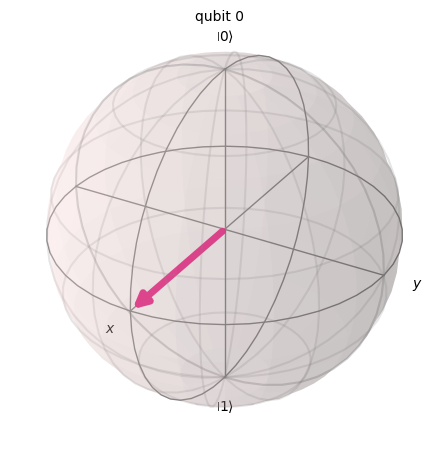

In [ ]:
def make_plus_state():
    qc = QuantumCircuit(1)
    qc.h(0)   # H|0> = |+>
    return qc

sv_plus = Statevector(make_plus_state())
print("Initial state |+> = 1/sqrt(2)(|0> + |1>):")
display(array_to_latex(sv_plus, prefix="|+\\rangle = "))
plot_bloch_multivector(sv_plus)

### 2.2 — Apply Each Gate and Visualize

 Gate: Y


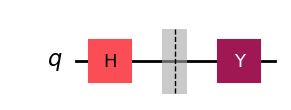

State vector after Y gate:


<IPython.core.display.Latex object>

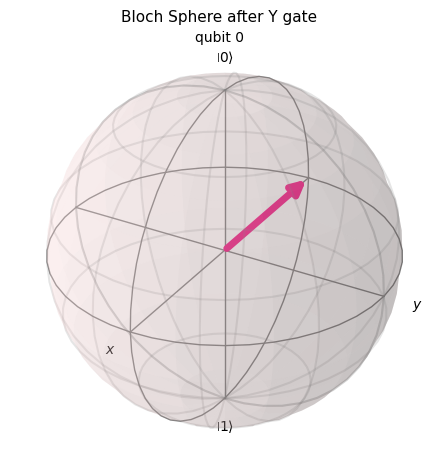

 Gate: Z


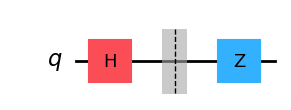

State vector after Z gate:


<IPython.core.display.Latex object>

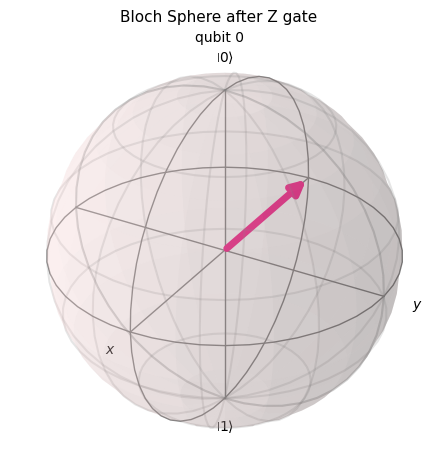

 Gate: P(π/4)


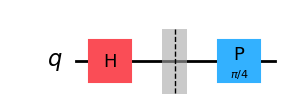

State vector after P(π/4) gate:


<IPython.core.display.Latex object>

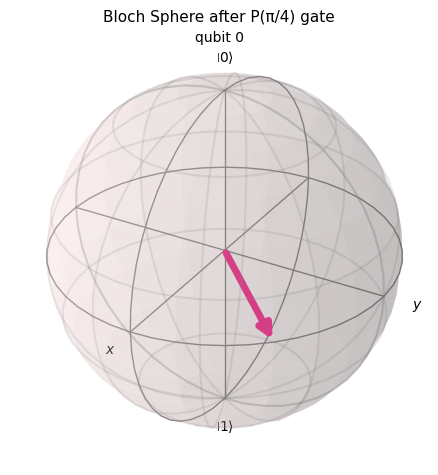

 Gate: S


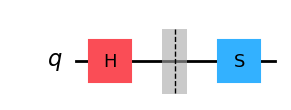

State vector after S gate:


<IPython.core.display.Latex object>

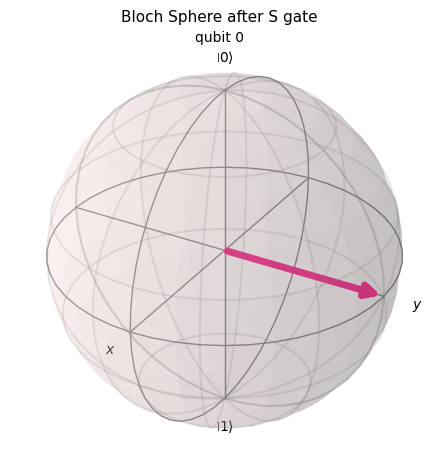

 Gate: SDG


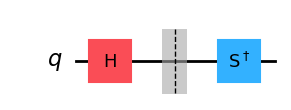

State vector after SDG gate:


<IPython.core.display.Latex object>

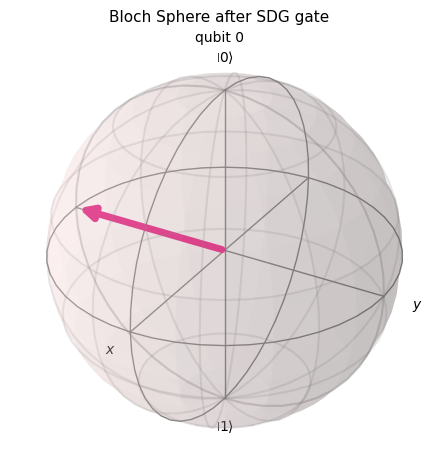

 Gate: T


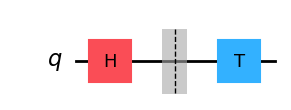

State vector after T gate:


<IPython.core.display.Latex object>

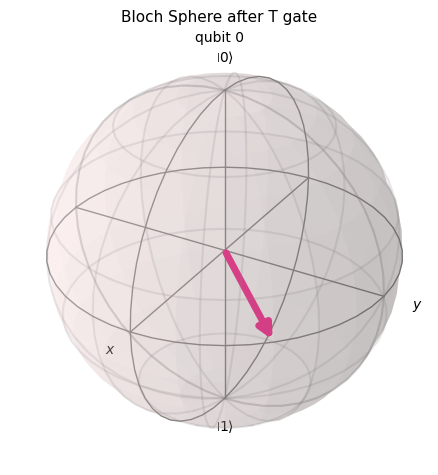

 Gate: TDG


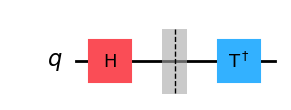

State vector after TDG gate:


<IPython.core.display.Latex object>

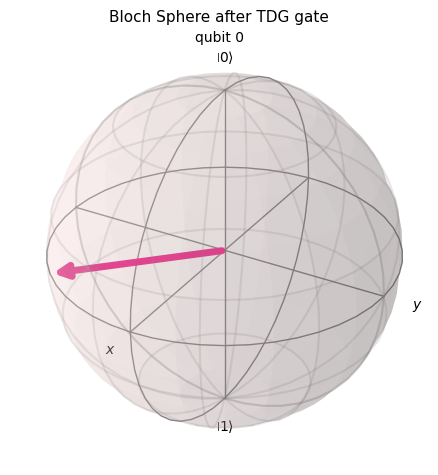

In [ ]:
def apply_gate_and_show(gate_name, phase_angle=None):
    qc = make_plus_state()   # Start from |+>
    qc.barrier()

    # Apply the requested gate
    if gate_name == 'Y':     qc.y(0)
    elif gate_name == 'Z':   qc.z(0)
    elif gate_name == 'P':   qc.p(phase_angle, 0)   # Phase gate P
    elif gate_name == 'S':   qc.s(0)
    elif gate_name == 'SDG': qc.sdg(0)
    elif gate_name == 'T':   qc.t(0)
    elif gate_name == 'TDG': qc.tdg(0)

    label = gate_name if phase_angle is None else f"P(π/4)"
    print(f"{'='*55}")
    print(f" Gate: {label}")
    print(f"{'='*55}")

    # Draw circuit
    display(qc.draw('mpl'))

    # Statevector
    sv = Statevector(qc)
    print(f"State vector after {label} gate:")
    display(array_to_latex(sv, prefix=f"|\\psi\\rangle = "))

    # Bloch sphere
    fig = plot_bloch_multivector(sv)
    fig.suptitle(f'Bloch Sphere after {label} gate', fontsize=11)
    display(fig)
    plt.close('all')

# Run for all required gates
apply_gate_and_show('Y')
apply_gate_and_show('Z')
apply_gate_and_show('P', phase_angle=np.pi/4)   # Phase gate with lambda = pi/4
apply_gate_and_show('S')
apply_gate_and_show('SDG')
apply_gate_and_show('T')
apply_gate_and_show('TDG')

### 2.3 — All Gates Side-by-Side on Bloch Sphere

In [ ]:
from qiskit.visualization import plot_bloch_vector

gates = {
    'Y':   lambda qc: qc.y(0),
    'Z':   lambda qc: qc.z(0),
    'P(π/4)': lambda qc: qc.p(np.pi/4, 0),
    'S':   lambda qc: qc.s(0),
    'S†':  lambda qc: qc.sdg(0),
    'T':   lambda qc: qc.t(0),
    'T†':  lambda qc: qc.tdg(0),
}

statevectors = {}
for name, gate_fn in gates.items():
    qc = make_plus_state()
    gate_fn(qc)
    statevectors[name] = Statevector(qc)


print(f"{'Gate':<10} {'State Vector (approx)':<45} {'|0> prob':>8} {'|1> prob':>8}")
print("-" * 75)
for name, sv in statevectors.items():
    probs = sv.probabilities()
    vec_str = str(np.round(sv.data, 3))
    print(f"{name:<10} {vec_str:<45} {probs[0]:>8.3f} {probs[1]:>8.3f}")

Gate       State Vector (approx)                         |0> prob |1> prob
---------------------------------------------------------------------------
Y          [0.-0.707j 0.+0.707j]                            0.500    0.500
Z          [ 0.707+0.j -0.707+0.j]                          0.500    0.500
P(π/4)     [0.707+0.j  0.5  +0.5j]                          0.500    0.500
S          [0.707+0.j    0.   +0.707j]                      0.500    0.500
S†         [0.707+0.j    0.   -0.707j]                      0.500    0.500
T          [0.707+0.j  0.5  +0.5j]                          0.500    0.500
T†         [0.707+0.j  0.5  -0.5j]                          0.500    0.500


---
# Experiment 3: Introduction to State Vector Simulator

Draw the following circuits and show measurement results using the **Sampler primitive** of the state vector simulator.

- **(a)** Control qubit + H–Z–H on second qubit
- **(b)** H–CNOT–H on both qubits  
- **(c)** Two-qubit circuit with cascaded CNOTs
- **(d)** Three-qubit circuit with cascaded CNOTs

### 3.1 — Circuit (a): Controlled-Z equivalent using H–Z–H

Circuit (a): Control + H–Z–H


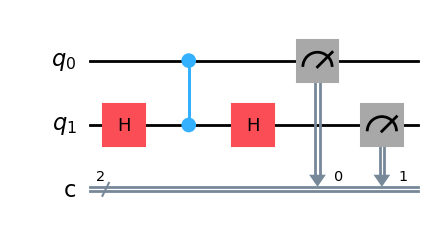

In [ ]:
# Circuit (a):
# q0: ──●──────────
# q1: ──H──Z──H──
qc_a = QuantumCircuit(2, 2)
qc_a.h(1)
qc_a.cz(0, 1)
qc_a.h(1)
qc_a.measure([0, 1], [0, 1])

print("Circuit (a): Control + H–Z–H")
qc_a.draw('mpl')

Circuit (a) — exact layout:


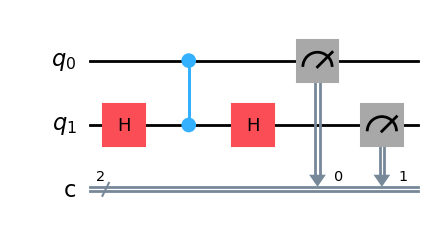

In [ ]:
# q0: ──●──────────
# q1: ──H──Z──H──
qc_a2 = QuantumCircuit(2, 2)
qc_a2.h(1)
qc_a2.z(1)
qc_a2.h(1)
qc_a_exact = QuantumCircuit(2, 2)
qc_a_exact.h(1)
qc_a_exact.cz(0, 1)
qc_a_exact.h(1)
qc_a_exact.measure([0, 1], [0, 1])

print("Circuit (a) — exact layout:")
qc_a_exact.draw('mpl')

### 3.2 — Circuit (b): H–CNOT–H on both qubits

Circuit (b): H–CNOT–H on both qubits


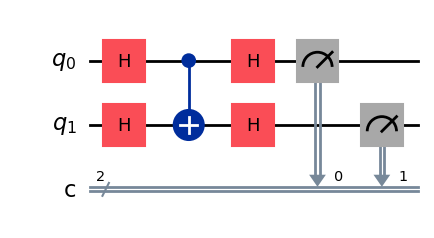

In [ ]:
# Circuit (b):
# q0: ──H──●──H──
# q1: ──H──X──H──

qc_b = QuantumCircuit(2, 2)
qc_b.h(0)
qc_b.h(1)
qc_b.cx(0, 1)
qc_b.h(0)
qc_b.h(1)
qc_b.measure([0, 1], [0, 1])

print("Circuit (b): H–CNOT–H on both qubits")
qc_b.draw('mpl')

### 3.3 — Circuit (c): Cascaded CNOTs (2 qubit)

Circuit (c): Cascaded CNOTs (2-qubit)


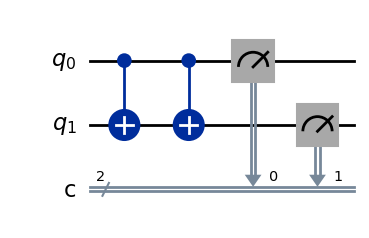

In [ ]:
# Circuit (c): 2-qubit cascaded CNOTs
# q0: ──●──●──
# q1: ──⊕──⊕──

qc_c = QuantumCircuit(2, 2)
qc_c.cx(0, 1)
qc_c.cx(0, 1)
qc_c.measure([0, 1], [0, 1])

print("Circuit (c): Cascaded CNOTs (2-qubit)")
qc_c.draw('mpl')

### 3.4 — Circuit (d): Cascaded CNOTs (3 qubit)

Circuit (d): Cascaded CNOTs (3-qubit)


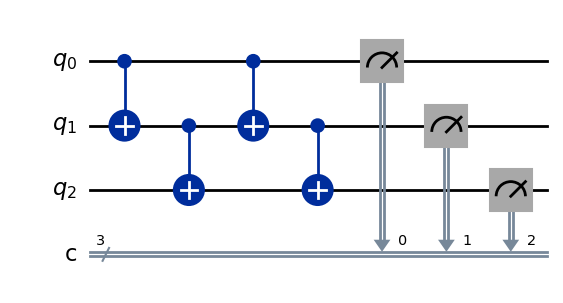

In [ ]:
# Circuit (d): 3-qubit cascaded CNOTs
# q0: ──●──────●──
# q1: ──⊕──●──⊕──
# q2: ─────⊕─────

qc_d = QuantumCircuit(3, 3)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.measure([0, 1, 2], [0, 1, 2])

print("Circuit (d): Cascaded CNOTs (3-qubit)")
qc_d.draw('mpl')

### 3.5 — Run All Circuits with AerSampler (StatevectorSimulator)

In [ ]:
from qiskit_aer.primitives import SamplerV2 as AerSampler

shots   = 4096
sampler = AerSampler()

circuits = {
    '(a) Control + H–Z–H': qc_a_exact,
    '(b) H–CNOT–H':        qc_b,
    '(c) Cascaded CNOT 2q':qc_c,
    '(d) Cascaded CNOT 3q':qc_d,
}

results = {}
for name, qc in circuits.items():
    job = sampler.run([qc], shots=shots)
    res = job.result()

    counts = res[0].data.meas.get_counts() if hasattr(res[0].data, 'meas') \
             else res[0].data.c.get_counts()
    results[name] = counts
    print(f"\n{name}")
    print(f"  Counts: {counts}")


(a) Control + H–Z–H
  Counts: {'00': 4096}

(b) H–CNOT–H
  Counts: {'00': 4096}

(c) Cascaded CNOT 2q
  Counts: {'00': 4096}

(d) Cascaded CNOT 3q
  Counts: {'000': 4096}


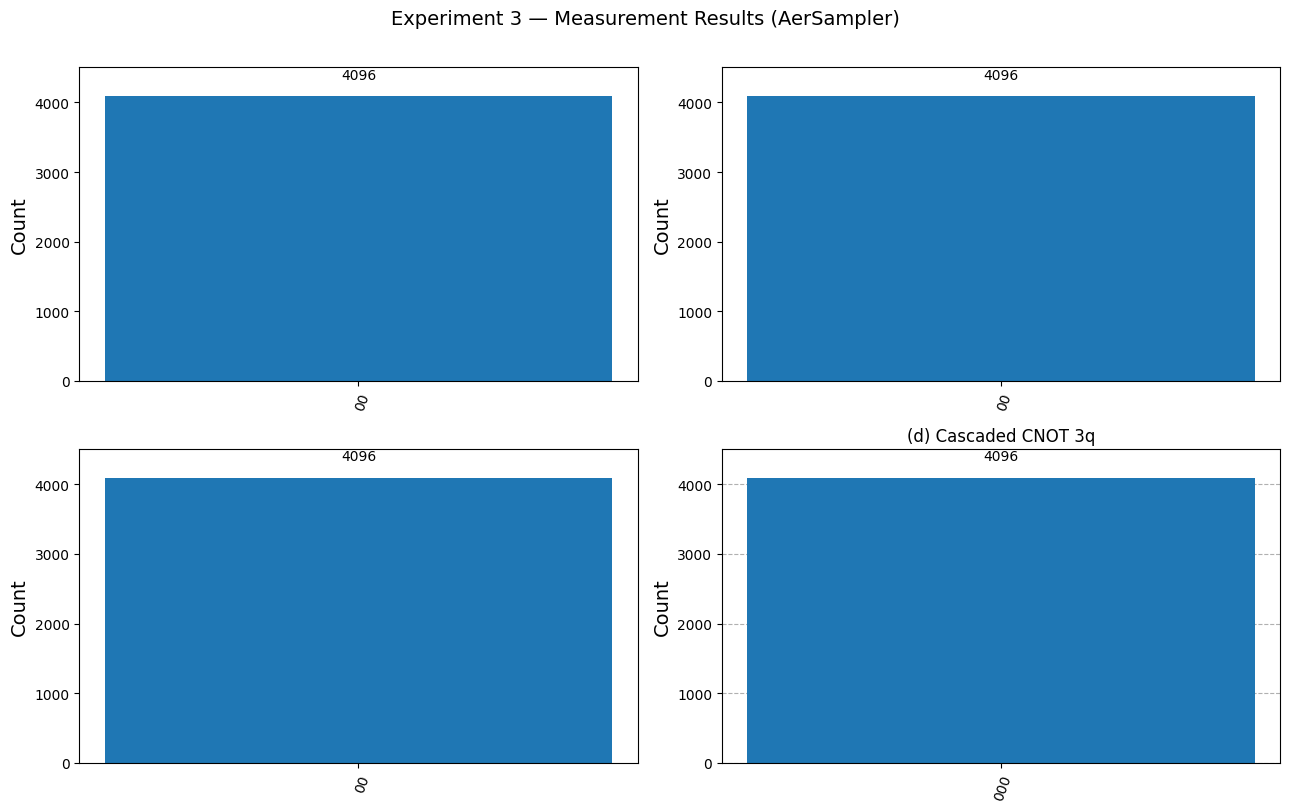

In [ ]:
# Plot all four histograms
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, counts) in zip(axes, results.items()):
    plot_histogram(counts, ax=ax, title=name)

plt.suptitle("Experiment 3 — Measurement Results (AerSampler)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.6 — State Vector Analysis (Before Measurement)

In [ ]:
# Inspect statevectors of each circuit
circuits_no_meas = {
    '(a) Control + H–Z–H': qc_a_exact.remove_final_measurements(inplace=False),
    '(b) H–CNOT–H':        qc_b.remove_final_measurements(inplace=False),
    '(c) Cascaded CNOT 2q':qc_c.remove_final_measurements(inplace=False),
    '(d) Cascaded CNOT 3q':qc_d.remove_final_measurements(inplace=False),
}

for name, qc in circuits_no_meas.items():
    sv = Statevector(qc)
    print(f"\n{name}")
    display(array_to_latex(sv, prefix="|\\psi\\rangle = "))


(a) Control + H–Z–H


<IPython.core.display.Latex object>


(b) H–CNOT–H


<IPython.core.display.Latex object>


(c) Cascaded CNOT 2q


<IPython.core.display.Latex object>


(d) Cascaded CNOT 3q


<IPython.core.display.Latex object>

---
# Experiment 4: Introduction to Qiskit Runtime and Execution on Real Hardware

Run all circuits from Experiment 3 using the **Estimator primitive** and the **SamplerV2** from `qiskit-ibm-runtime`. The optional section shows how to run on real IBM Quantum hardware.

### 4.1 — Run All Exp-3 Circuits with AerSampler (Local Runtime Simulation)

In [ ]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

shots   = 4096
sampler = AerSampler()

exp4_circuits = [
    ('(a) Control + H–Z–H', qc_a_exact),
    ('(b) H–CNOT–H',        qc_b),
    ('(c) Cascaded CNOT 2q',qc_c),
    ('(d) Cascaded CNOT 3q',qc_d),
]

exp4_results = {}
for name, qc in exp4_circuits:
    job    = sampler.run([qc], shots=shots)
    res    = job.result()
    try:
        counts = res[0].data.meas.get_counts()
    except AttributeError:
        counts = res[0].data.c.get_counts()
    exp4_results[name] = counts
    print(f"{name}: {counts}")

(a) Control + H–Z–H: {'00': 4096}
(b) H–CNOT–H: {'00': 4096}
(c) Cascaded CNOT 2q: {'00': 4096}
(d) Cascaded CNOT 3q: {'000': 4096}


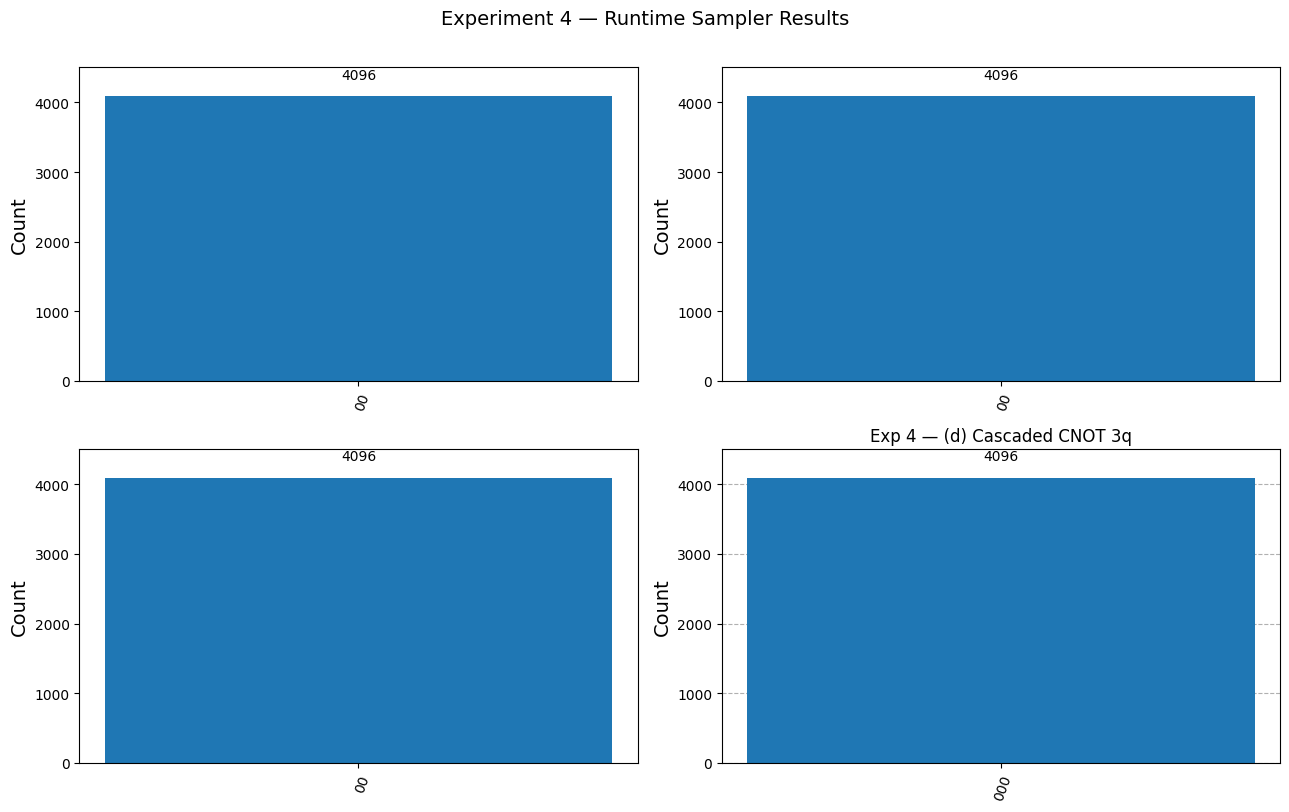

In [ ]:
# Plot Experiment 4 results
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (name, counts) in zip(axes, exp4_results.items()):
    plot_histogram(counts, ax=ax, title=f"Exp 4 — {name}")

plt.suptitle("Experiment 4 — Runtime Sampler Results", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 — Estimator Primitive: Measure Observables

The **Estimator** primitive computes expectation values $\langle O \rangle = \langle \psi | O | \psi \rangle$ for a given observable $O$, without collapsing to classical bits.

In [ ]:
estimator = AerEstimator()

# Define observables for each circuit
observables_map = {
    '(a) Control + H–Z–H': SparsePauliOp('ZZ'),
    '(b) H–CNOT–H':        SparsePauliOp('ZZ'),
    '(c) Cascaded CNOT 2q':SparsePauliOp('ZZ'),
    '(d) Cascaded CNOT 3q':SparsePauliOp('ZZZ'),
}

print("Estimator Results — Expectation Values <ZZ> or <ZZZ>")
print("=" * 55)

for name, qc in exp4_circuits:
    qc_nm  = qc.remove_final_measurements(inplace=False)
    obs    = observables_map[name]
    job    = estimator.run([(qc_nm, obs)])
    result = job.result()
    expval = result[0].data.evs
    print(f"{name:<30}  <O> = {expval:+.6f}")

Estimator Results — Expectation Values <ZZ> or <ZZZ>
(a) Control + H–Z–H             <O> = +1.000000
(b) H–CNOT–H                    <O> = +1.000000
(c) Cascaded CNOT 2q            <O> = +1.000000
(d) Cascaded CNOT 3q            <O> = +1.000000
